In [110]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### Load IRIS DataSet

In [111]:
df = sb.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Exploratory Data Analysis

In [112]:
# Check if any rows has null values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [113]:
# Check what all unique species exists
df["species"].unique()
# This is the multi class classification problem

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [114]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

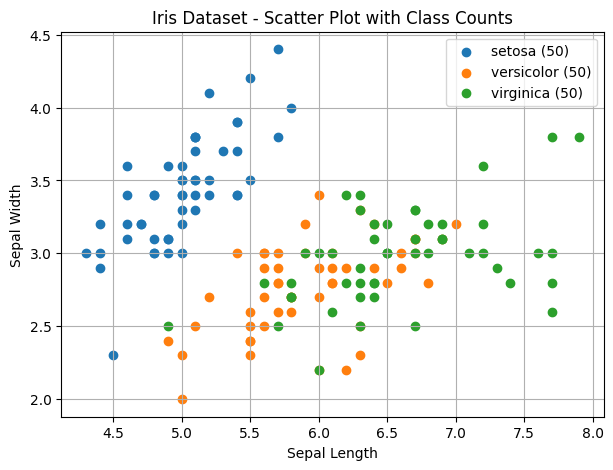

In [115]:
# Get counts of all the class and plot in on the scatter graph: Sepal Data
counts = df["species"].value_counts()

plt.figure(figsize=(7,5))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        label=f"{species} ({counts[species]})"
    )
    # break

plt.title("Iris Dataset - Scatter Plot with Class Counts")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.grid(True)
plt.show()

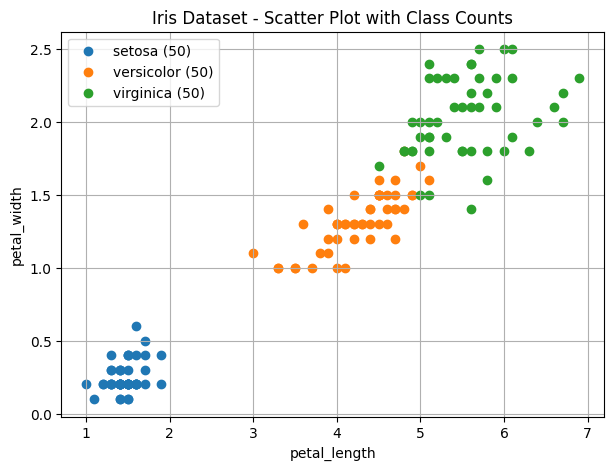

In [116]:
# Get counts of all the class and plot in on the scatter graph: Petal Data
# Love the way how scatter plot shows the data based on different features🙂
counts = df["species"].value_counts()

plt.figure(figsize=(7,5))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=f"{species} ({counts[species]})"
    )

plt.title("Iris Dataset - Scatter Plot with Class Counts")
plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.legend()
plt.grid(True)
plt.show()

In [117]:
# Numerical representation of species column
# Note: LabelEncoder or OHE can also be used for encoding the classes
df["species"] = df["species"].map({"setosa": 0, "versicolor": 1, "virginica": 2})
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [118]:
# Split data into dependent and independent columns
X = df.drop("species")
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [119]:
model = LogisticRegression()

parameters = {"penalty" : ["l1", "l2", "elasticnet"], 
               "C" : [0.001, 0.01, 0.1, 1, 10, 100],
               "max_itr": [400, 800, 1000]} #l2 penalty is a default choice.